In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def getCSV(csv):
    dfl = pd.read_csv(csv)
    return dfl
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\NewEarners-Money.csv') 
print(df)

            Statistic Label  Year  \
0      Mean Weekly Earnings  2022   
1      Mean Weekly Earnings  2022   
2      Mean Weekly Earnings  2022   
3      Mean Weekly Earnings  2022   
4      Mean Weekly Earnings  2022   
..                      ...   ...   
259  Median Annual Earnings  2023   
260  Median Annual Earnings  2023   
261  Median Annual Earnings  2023   
262  Median Annual Earnings  2023   
263  Median Annual Earnings  2023   

                                           Nationality  \
0                                               Brazil   
1                                               Brazil   
2                                               Brazil   
3                                                India   
4                                                India   
..                                                 ...   
259  United Kingdom of Great Britain and Northern I...   
260  United Kingdom of Great Britain and Northern I...   
261                              

In [11]:
age = "25 - 64 years"
year=2023
label="Mean Weekly Earnings"
filtered_df = df[(df['Youth or General Employment Group']==age)&(df['Year']==year)]
filtered_df = filtered_df[filtered_df['Nationality']!="All nationalities"]
filtered_df = filtered_df[filtered_df['Statistic Label']==label]

In [72]:
def changeNames(name):
    switch = {
        "Other countries (3)": "Other",
        "Ireland": "Irish",
        "Brazil": "Brazilian",
        "Spain": "Spanish",
        "Italy": "Italian",
        "Poland": "Polish",
        "Romania": "Romanian",
        "Ukraine": "Ukrainian",
        "United Kingdom of Great Britain and Northern Ireland (the)": "British",
        "India": "Indian"
    }
    if name not in switch:
        return name 
    else:
        return switch[name]

filtered_df["Nationality"] = filtered_df["Nationality"].apply(changeNames)
print(filtered_df)

               Statistic Label  Year Nationality  \
1   Proportion of new entrants  2022   Brazilian   
4   Proportion of new entrants  2022      Indian   
7   Proportion of new entrants  2022       Irish   
10  Proportion of new entrants  2022     Italian   
13  Proportion of new entrants  2022       Other   
16  Proportion of new entrants  2022      Polish   
19  Proportion of new entrants  2022    Romanian   
22  Proportion of new entrants  2022     Spanish   
25  Proportion of new entrants  2022   Ukrainian   
28  Proportion of new entrants  2022          UK   
34  Proportion of new entrants  2023   Brazilian   
37  Proportion of new entrants  2023      Indian   
40  Proportion of new entrants  2023       Irish   
43  Proportion of new entrants  2023     Italian   
46  Proportion of new entrants  2023       Other   
49  Proportion of new entrants  2023      Polish   
52  Proportion of new entrants  2023    Romanian   
55  Proportion of new entrants  2023     Spanish   
58  Proporti

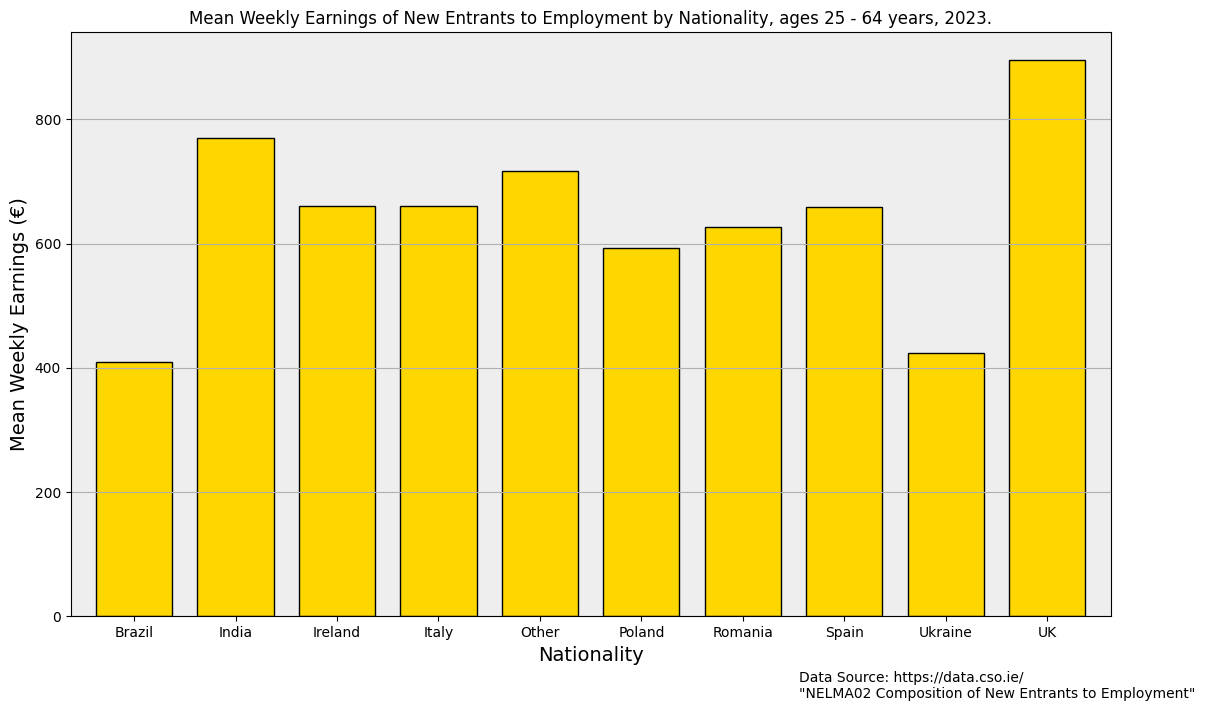

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(13, 8))

filtered_df.plot(x="Nationality", y="VALUE", kind="bar", width=0.75, edgecolor="black", color="#FFD700", ax=ax)

title_string = label + " of New Entrants to Employment by Nationality, ages "+age+", "+str(year)+"."

plt.title(title_string)
plt.xlabel('Nationality', fontsize=14)
plt.ylabel(label+' (€)', fontsize=14)
plt.xticks(rotation=0) 
#ax.set_xlim(200,550)
ax.set_facecolor('#EEEEEE') 
ax.get_legend().remove()
plt.grid(True, axis="y")

plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.17)
plt.text(0.7, -0.14, "Data Source: https://data.cso.ie/ \n\"NELMA02 Composition of New Entrants to Employment\"", ha='left', transform=ax.transAxes)

save_fig = 'NewEarners'+label+age+'.png'
plt.savefig(save_fig)

# Show the plot
plt.show()


In [73]:
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\NewEarners-Percentage.csv')
print(df)

               Statistic Label  Year  \
0   Proportion of new entrants  2022   
1   Proportion of new entrants  2022   
2   Proportion of new entrants  2022   
3   Proportion of new entrants  2022   
4   Proportion of new entrants  2022   
..                         ...   ...   
61  Proportion of new entrants  2023   
62  Proportion of new entrants  2023   
63  Proportion of new entrants  2023   
64  Proportion of new entrants  2023   
65  Proportion of new entrants  2023   

                                          Nationality  \
0                                              Brazil   
1                                              Brazil   
2                                              Brazil   
3                                               India   
4                                               India   
..                                                ...   
61  United Kingdom of Great Britain and Northern I...   
62  United Kingdom of Great Britain and Northern I...   
63    

In [74]:
age = "25 - 64 years"
filtered_df = df[df['Youth or General Employment Group']==age]
filtered_df = filtered_df[filtered_df['Nationality']!="All nationalities"]
filtered_df["Nationality"] = filtered_df["Nationality"].apply(changeNames)

two_two_df = filtered_df[filtered_df['Year']==2022]
two_three_df = filtered_df[filtered_df['Year']==2023]

In [75]:
merged = pd.merge(two_two_df, two_three_df, on="Nationality")
print(merged)

            Statistic Label_x  Year_x Nationality  \
0  Proportion of new entrants    2022   Brazilian   
1  Proportion of new entrants    2022      Indian   
2  Proportion of new entrants    2022       Irish   
3  Proportion of new entrants    2022     Italian   
4  Proportion of new entrants    2022       Other   
5  Proportion of new entrants    2022      Polish   
6  Proportion of new entrants    2022    Romanian   
7  Proportion of new entrants    2022     Spanish   
8  Proportion of new entrants    2022   Ukrainian   
9  Proportion of new entrants    2022     British   

  Youth or General Employment Group_x UNIT_x  VALUE_x  \
0                       25 - 64 years      %      4.7   
1                       25 - 64 years      %      5.5   
2                       25 - 64 years      %     19.5   
3                       25 - 64 years      %      1.6   
4                       25 - 64 years      %     16.5   
5                       25 - 64 years      %      1.8   
6                

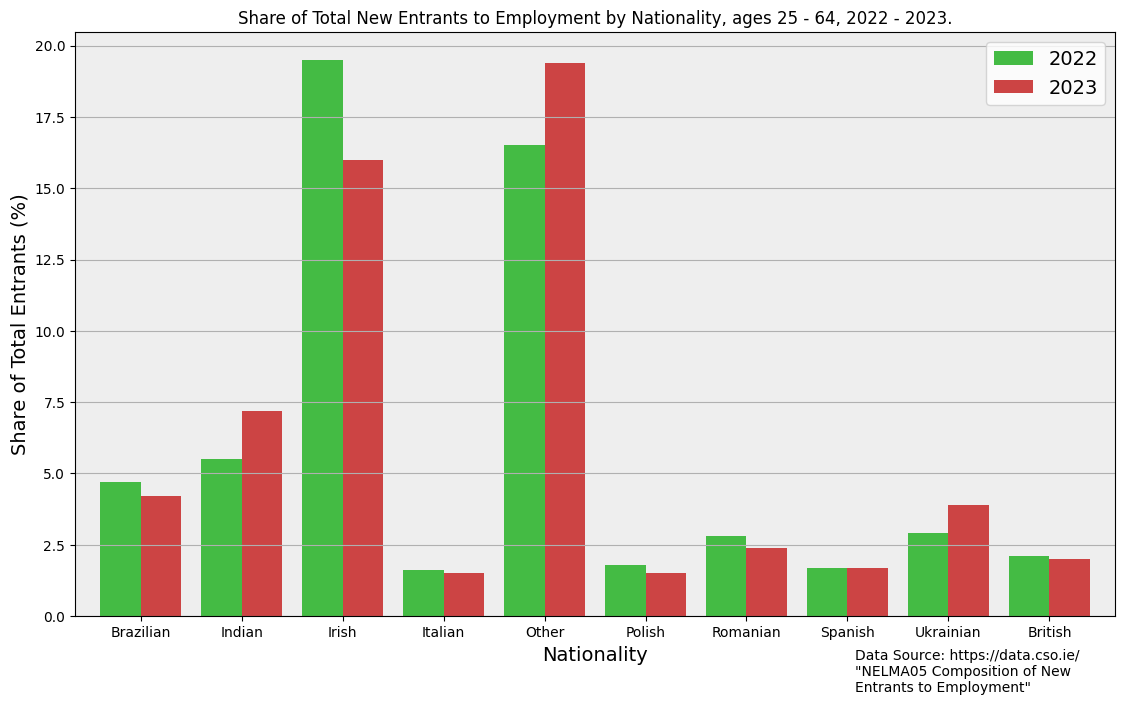

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(13, 8))

merged.plot(kind='bar', x='Nationality', y=['VALUE_x', 'VALUE_y'], color=['#4b4', '#c44'], label=["2022", "2023"], width=0.8, ax=ax)

title_string = "Share of Total New Entrants to Employment by Nationality, ages 25 - 64, 2022 - 2023."

plt.title(title_string)
plt.xlabel('Nationality', fontsize=14)
plt.ylabel('Share of Total Entrants (%)', fontsize=14)
plt.xticks(rotation=0) 
#ax.set_xlim(200,550)
ax.set_facecolor('#EEEEEE') 
ax.legend(fontsize=14) 
plt.grid(True, axis="y")


plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.17)
plt.text(0.75, -0.13, "Data Source: https://data.cso.ie/ \n\"NELMA05 Composition of New \nEntrants to Employment\"", ha='left', transform=ax.transAxes)

save_fig = 'NewEarnersShareCompare-'+age+'.png'
plt.savefig(save_fig)

# Show the plot
plt.show()


In [ ]:
fig, ax = plt.subplots(1,1,figsize=(12,8))

counties_df['Pop_Year1'] = counties_df['PopList'].apply(lambda x: x[0])
counties_df['Pop_Year2'] = counties_df['PopList'].apply(lambda x: x[1])
counties_df.plot(kind='bar', x='County', y=['Pop_Year1', 'Pop_Year2'], color=['red', 'blue'], width=0.8, ax=ax)

# Customize the plot
plt.title('Net population change per county, '+str(year)+'-2022', fontsize=16)
plt.xlabel('Counties', fontsize=14)
plt.xticks(rotation=0)
plt.ylabel('Population (millions)', fontsize=14)
ax.set_facecolor('#EEEEEE') 
plt.grid(True)
plt.tight_layout()
plt.legend(title='Year', loc='upper center', labels=[year, 2022], fontsize='20')

plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.17)
plt.text(0.68, -0.12, "Data Source: https://data.cso.ie/ \n\"A0102 Population at Each Census Since 1841\"", ha='left', transform=ax.transAxes)


#plt.savefig(str(year)+'-2022-Population_Change_Barchart.png')

plt.show()